In [1]:
import os

os.environ['HTTP_PROXY'] = 'http://127.0.0.1:10808'
os.environ['HTTPS_PROXY'] = 'http://127.0.0.1:10808'
os.environ['NO_PROXY'] = 'localhost,127.0.0.1'

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, PolynomialFeatures
import kagglehub
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.linear_model import Ridge, Lasso, LinearRegression, LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline

/home/miad/.local/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:

# Download latest version
path = kagglehub.dataset_download("austinreese/craigslist-carstrucks-data")

print("Path to dataset files:", path)

Path to dataset files: /home/miad/.cache/kagglehub/datasets/austinreese/craigslist-carstrucks-data/versions/10


In [4]:
for f in os.listdir(path):
    print(f)

vehicles.csv


In [5]:
pd.set_option('display.float_format', '{:.2f}'.format)
csv_path = os.path.join(path, "vehicles.csv")
df = pd.read_csv(csv_path)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  object 
 2   region        426880 non-null  object 
 3   region_url    426880 non-null  object 
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  object 
 7   model         421603 non-null  object 
 8   condition     252776 non-null  object 
 9   cylinders     249202 non-null  object 
 10  fuel          423867 non-null  object 
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  object 
 13  transmission  424324 non-null  object 
 14  VIN           265838 non-null  object 
 15  drive         296313 non-null  object 
 16  size          120519 non-null  object 
 17  type          334022 non-null  object 
 18  pain

In [7]:
df = df.drop(columns=["id", "url","region_url","VIN", "description", "image_url"])
# dropping county since it is all null
# size and posting_datecause it has a lot of null
# paint does not have corr
df = df.drop(columns=["county", "lat", "long", "region", "paint_color", "size", "posting_date", "title_status"])

# dropping rows with null value in price, year, model, manufacturer
df = df.dropna(subset=['price', 'year', 'model', 'manufacturer'])

In [8]:

# Fill missing categorical features with 'unknown'
for col in ['condition', 'drive', 'type', 'fuel']:
    df[col] = df[col].fillna('unknown')

# Fill missing transmission with most common value
df['transmission'] = df['transmission'].fillna(df['transmission'].mode()[0])

# Clean cylinders (convert text like '6 cylinders' → 6)
df['cylinders'] = df['cylinders'].str.extract(r'(\d+)').astype(float)
df['cylinders'] = df['cylinders'].fillna(df['cylinders'].median())

df = df[df["odometer"].between(0, 350_000)]
df = df[df["price"].between(300, 80_000)]
df = df[df["year"] > 1980]

In [9]:
# convert objects to category
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype('category')

In [10]:
#    keep=False marks ALL rows that are part of any duplicate set as True.
all_duplicates_mask = df.duplicated(keep=False)

all_duplicate_rows_df = df[all_duplicates_mask]

# 3. Sort them to see them grouped together
print("All rows that are part of a duplicate set:")
display(all_duplicate_rows_df.sort_values(by=['manufacturer', 'model', 'year', 'price']))

print(f"Shape before dropping duplicates: {df.shape}")

df = df.drop_duplicates()

print(f"Shape after dropping duplicates: {df.shape}")
print(f"Total duplicates found: {df.duplicated().sum()}")

All rows that are part of a duplicate set:


,price,year,manufacturer,model,condition,cylinders,fuel,odometer,transmission,drive,type,state
332564,9999,2003.00,acura,3.2 cl type s,excellent,6.00,gas,136371.00,manual,unknown,coupe,pa
333080,9999,2003.00,acura,3.2 cl type s,excellent,6.00,gas,136371.00,manual,unknown,coupe,pa
56686,7799,2008.00,acura,3.2 tl,excellent,6.00,gas,117000.00,automatic,unknown,unknown,ca
56687,7799,2008.00,acura,3.2 tl,excellent,6.00,gas,117000.00,automatic,unknown,unknown,ca
108696,3695,2001.00,acura,cl,unknown,6.00,gas,195578.00,automatic,unknown,coupe,fl
...,...,...,...,...,...,...,...,...,...,...,...,...
42957,42998,2018.00,volvo,xc90t6 awd 24733 miles,excellent,6.00,gas,24733.00,automatic,4wd,SUV,ca
57532,42998,2018.00,volvo,xc90t6 awd 24733 miles,excellent,6.00,gas,24733.00,automatic,4wd,SUV,ca
57582,42998,2018.00,volvo,xc90t6 awd 24733 miles,excellent,6.00,gas,24733.00,automatic,4wd,SUV,ca
57869,42998,2018.00,volvo,xc90t6 awd 24733 miles,excellent,6.00,gas,24733.00,automatic,4wd,SUV,ca


Shape before dropping duplicates: (357429, 12)
Shape after dropping duplicates: (250995, 12)
Total duplicates found: 0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 250995 entries, 27 to 426879
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype   
---  ------        --------------   -----   
 0   price         250995 non-null  int64   
 1   year          250995 non-null  float64 
 2   manufacturer  250995 non-null  category
 3   model         250995 non-null  category
 4   condition     250995 non-null  category
 5   cylinders     250995 non-null  float64 
 6   fuel          250995 non-null  category
 7   odometer      250995 non-null  float64 
 8   transmission  250995 non-null  category
 9   drive         250995 non-null  category
 10  type          250995 non-null  category
 11  state         250995 non-null  category
dtypes: category(8), float64(3), int64(1)
memory usage: 12.4 MB


In [12]:
df.describe()

,price,year,cylinders,odometer
count,250995.00,250995.00,250995.00,250995.00
mean,17564.04,2011.56,5.92,97422.85
std,13595.21,6.54,1.25,63431.76
min,300.00,1981.00,3.00,0.00
25%,6980.00,2008.00,6.00,42835.50
50%,13995.00,2013.00,6.00,93424.00
75%,25487.50,2017.00,6.00,140371.50
max,80000.00,2022.00,12.00,350000.00


In [13]:
df.isnull().sum().sort_values(ascending=False)

price           0
year            0
manufacturer    0
model           0
condition       0
cylinders       0
fuel            0
odometer        0
transmission    0
drive           0
type            0
state           0
dtype: int64

In [14]:
df.shape

(250995, 12)

In [15]:
df.tail()

,price,year,manufacturer,model,condition,cylinders,fuel,odometer,transmission,drive,type,state
426875,23590,2019.00,nissan,maxima s sedan 4d,good,6.00,gas,32226.00,other,fwd,sedan,wy
426876,30590,2020.00,volvo,s60 t5 momentum sedan 4d,good,6.00,gas,12029.00,other,fwd,sedan,wy
426877,34990,2020.00,cadillac,xt4 sport suv 4d,good,6.00,diesel,4174.00,other,unknown,hatchback,wy
426878,28990,2018.00,lexus,es 350 sedan 4d,good,6.00,gas,30112.00,other,fwd,sedan,wy
426879,30590,2019.00,bmw,4 series 430i gran coupe,good,6.00,gas,22716.00,other,rwd,coupe,wy


In [16]:
df.describe()

,price,year,cylinders,odometer
count,250995.00,250995.00,250995.00,250995.00
mean,17564.04,2011.56,5.92,97422.85
std,13595.21,6.54,1.25,63431.76
min,300.00,1981.00,3.00,0.00
25%,6980.00,2008.00,6.00,42835.50
50%,13995.00,2013.00,6.00,93424.00
75%,25487.50,2017.00,6.00,140371.50
max,80000.00,2022.00,12.00,350000.00


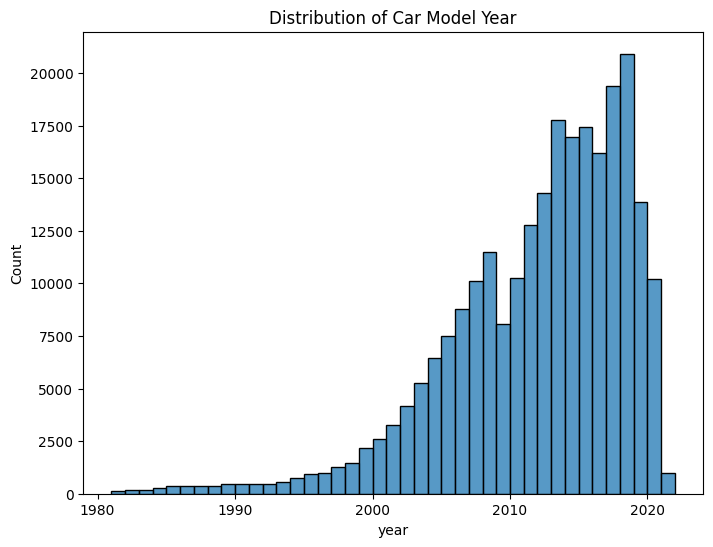

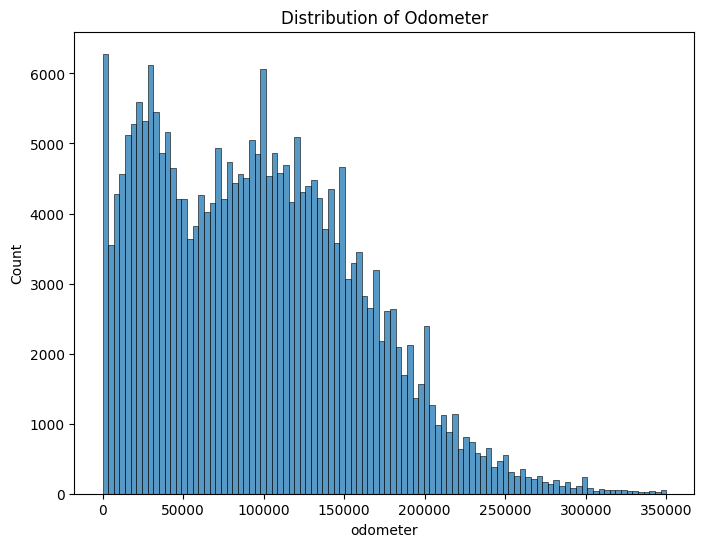

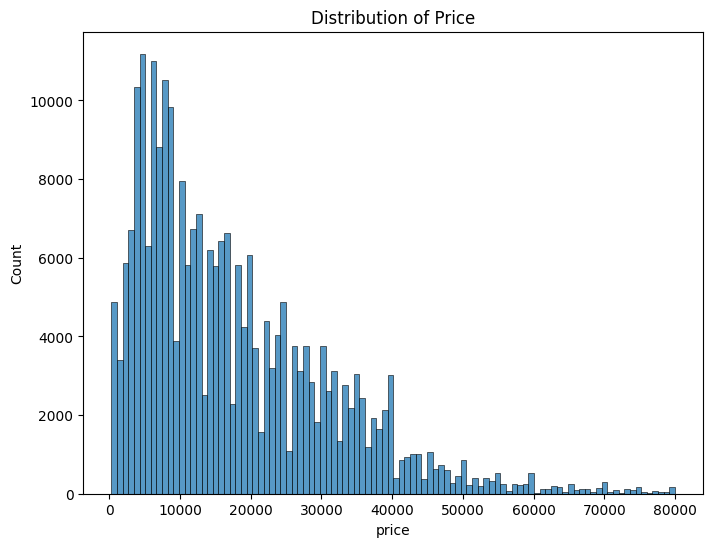

/tmp/ipykernel_78704/3023334624.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cylinders', data=df, palette='viridis')


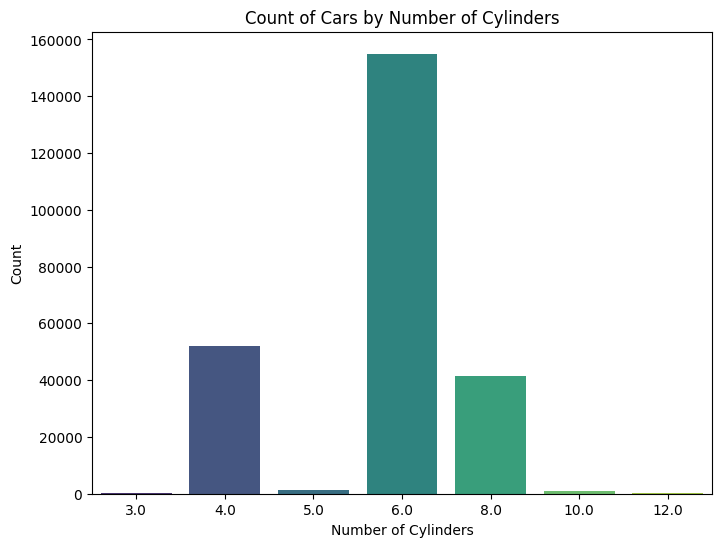

In [17]:
# --- Plot 1: Histogram for 'year' ---
# We use binwidth=1 to get a separate bar for each year.
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='year', binwidth=1)
plt.title('Distribution of Car Model Year')
plt.show()


# --- Plot 2: Histogram for 'odometer' ---
# Your plot has many bins. The default 'auto' might work,
# but setting a specific number like bins=100 gives this granular look.
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='odometer', bins=100)
plt.title('Distribution of Odometer')
plt.show()


# --- Plot 3: Histogram for 'price' ---
# This plot also has many bins, so we'll set bins=100 again.
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='price', bins=100)
plt.title('Distribution of Price')
plt.show()

# --- Plot 4: Count Plot for 'cylinders' ---
# This plot also has many bins, so we'll set bins=100 again.
plt.figure(figsize=(8, 6))
sns.countplot(x='cylinders', data=df, palette='viridis') 
plt.title('Count of Cars by Number of Cylinders')
plt.xlabel('Number of Cylinders')
plt.ylabel('Count')
plt.show()

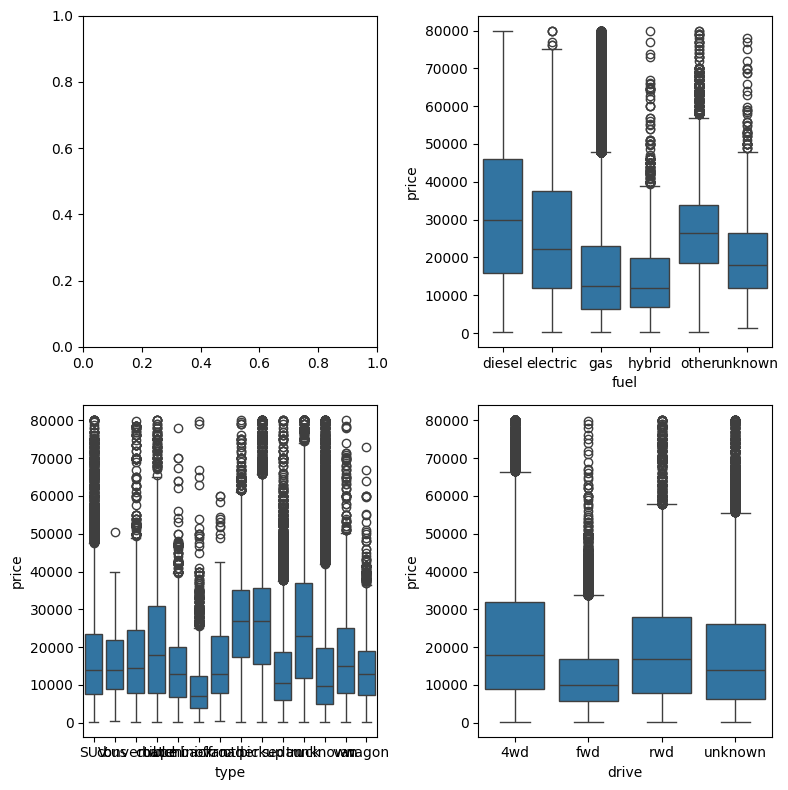

In [18]:
# Box plots for categorical variables
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
sns.boxplot(x='fuel', y='price', data=df, ax=axes[0, 1])
sns.boxplot(x='type', y='price', data=df, ax=axes[1, 0])
sns.boxplot(x='drive', y='price', data=df, ax=axes[1, 1])
plt.tight_layout()
plt.show()

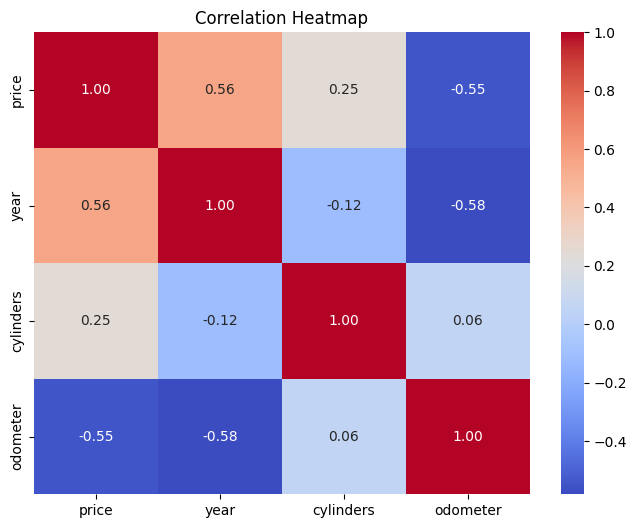

In [19]:
corr_matrix = df.select_dtypes(include="number").corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix, 
    annot=True,    
    cmap='coolwarm',
    fmt='.2f'      
)
plt.title('Correlation Heatmap')
plt.show()

# Feature Encoding

In [20]:

# Define the correct order, from worst to best
condition_order = ['salvage', 'fair', 'good', 'excellent', 'like new', 'new']


# Filter the list to only include categories present in your data
ordered_categories = [cat for cat in condition_order if cat in df['condition'].unique()]

# Initialize the encoder
ordinal_encoder = OrdinalEncoder(
    categories=[ordered_categories],
    handle_unknown='use_encoded_value', # Assigns a value (e.g., -1) to unknowns
    unknown_value=-1 
)

# Create the new encoded column
df['condition_encoded'] = ordinal_encoder.fit_transform(df[['condition']])
df = df.drop(columns=['condition'])

In [21]:
# Count frequency of each model
model_counts = df['model'].value_counts()
# Keep only models that appear at least 50 times
df = df[df['model'].isin(model_counts[model_counts >= 50].index)]


# Count frequency of each model
manu_counts = df['manufacturer'].value_counts()
# Keep only manufacturer that appear at least 100 times
df = df[df['manufacturer'].isin(manu_counts[manu_counts >= 100].index)]


In [22]:

low_cardinality_cols = ['fuel', 'transmission', 'drive', 'type', 'state']

print(f"\n--- One-Hot Encoding for {low_cardinality_cols} ---")
print(f"Shape before OHE: {df.shape}")

# drop_first=True is often recommended to avoid multicollinearity
df_encoded = pd.get_dummies(df, columns=low_cardinality_cols, drop_first=True)

print(f"Shape after OHE: {df_encoded.shape}")


--- One-Hot Encoding for ['fuel', 'transmission', 'drive', 'type', 'state'] ---
Shape before OHE: (166916, 12)
Shape after OHE: (166916, 80)


In [23]:

# high_cardinality_cols = ['model', 'manufacturer']

# print(f"\n--- One-Hot Encoding for {high_cardinality_cols} ---")
# print(f"Shape before OHE: {df_encoded.shape}")

# # drop_first=True is often recommended to avoid multicollinearity
# df_encoded = pd.get_dummies(df_encoded, columns=high_cardinality_cols, drop_first=True)

# print(f"Shape after OHE: {df_encoded.shape}")

for col in ['model', 'manufacturer']:
    freq_map = df[col].value_counts().to_dict()
    df_encoded[col + '_freq'] = df[col].map(freq_map)
df_encoded = df_encoded.drop(columns=['model', 'manufacturer'])

In [24]:
df_encoded

,price,year,cylinders,odometer,condition_encoded,fuel_electric,fuel_gas,fuel_hybrid,fuel_other,fuel_unknown,...,state_tx,state_ut,state_va,state_vt,state_wa,state_wi,state_wv,state_wy,model_freq,manufacturer_freq
27,33590,2014.00,8.00,57923.00,2.00,False,True,False,False,False,...,False,False,False,False,False,False,False,False,98,6184
28,22590,2010.00,8.00,71229.00,2.00,False,True,False,False,False,...,False,False,False,False,False,False,False,False,2978,24129
29,39590,2020.00,8.00,19160.00,2.00,False,True,False,False,False,...,False,False,False,False,False,False,False,False,222,24129
30,30990,2017.00,8.00,41124.00,2.00,False,True,False,False,False,...,False,False,False,False,False,False,False,False,105,16196
31,15000,2013.00,6.00,128000.00,3.00,False,True,False,False,False,...,False,False,False,False,False,False,False,False,293,30382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426871,17990,2018.00,6.00,34239.00,2.00,False,True,False,False,False,...,False,False,False,False,False,False,False,True,63,3429
426872,32590,2020.00,6.00,19059.00,2.00,False,True,False,False,False,...,False,False,False,False,False,False,False,True,96,2880
426874,33590,2018.00,6.00,30814.00,2.00,False,True,False,False,False,...,False,False,False,False,False,False,False,True,140,3035
426877,34990,2020.00,6.00,4174.00,2.00,False,False,False,False,False,...,False,False,False,False,False,False,False,True,190,2711


In [25]:
df_encoded.columns

Index(['price', 'year', 'cylinders', 'odometer', 'condition_encoded',
       'fuel_electric', 'fuel_gas', 'fuel_hybrid', 'fuel_other',
       'fuel_unknown', 'transmission_manual', 'transmission_other',
       'drive_fwd', 'drive_rwd', 'drive_unknown', 'type_bus',
       'type_convertible', 'type_coupe', 'type_hatchback', 'type_mini-van',
       'type_offroad', 'type_other', 'type_pickup', 'type_sedan', 'type_truck',
       'type_unknown', 'type_van', 'type_wagon', 'state_al', 'state_ar',
       'state_az', 'state_ca', 'state_co', 'state_ct', 'state_dc', 'state_de',
       'state_fl', 'state_ga', 'state_hi', 'state_ia', 'state_id', 'state_il',
       'state_in', 'state_ks', 'state_ky', 'state_la', 'state_ma', 'state_md',
       'state_me', 'state_mi', 'state_mn', 'state_mo', 'state_ms', 'state_mt',
       'state_nc', 'state_nd', 'state_ne', 'state_nh', 'state_nj', 'state_nm',
       'state_nv', 'state_ny', 'state_oh', 'state_ok', 'state_or', 'state_pa',
       'state_ri', 'state_sc', '

In [26]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 166916 entries, 27 to 426878
Data columns (total 80 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   price                166916 non-null  int64  
 1   year                 166916 non-null  float64
 2   cylinders            166916 non-null  float64
 3   odometer             166916 non-null  float64
 4   condition_encoded    166916 non-null  float64
 5   fuel_electric        166916 non-null  bool   
 6   fuel_gas             166916 non-null  bool   
 7   fuel_hybrid          166916 non-null  bool   
 8   fuel_other           166916 non-null  bool   
 9   fuel_unknown         166916 non-null  bool   
 10  transmission_manual  166916 non-null  bool   
 11  transmission_other   166916 non-null  bool   
 12  drive_fwd            166916 non-null  bool   
 13  drive_rwd            166916 non-null  bool   
 14  drive_unknown        166916 non-null  bool   
 15  type_bus             

In [27]:
numeric_cols = df_encoded.select_dtypes(include=['number']).columns
scaler = StandardScaler()
df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])


In [28]:
X = df_encoded.drop(columns=['price'])
y = df_encoded['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
# --- Train model ---
lasso_model = Lasso(alpha=0.0001, max_iter=1000)
lasso_model.fit(X_train, y_train)

# --- Predict ---
lasso_y_pred = lasso_model.predict(X_test)

# --- Evaluate ---
lasso_mae = mean_absolute_error(y_test, lasso_y_pred)
lasso_rmse = root_mean_squared_error(y_test, lasso_y_pred)
lasso_r2 = r2_score(y_test, lasso_y_pred)

print(f"Lasso MAE : {lasso_mae:,.2f}")
print(f"Lasso RMSE: {lasso_rmse:,.2f}")
print(f"Lasso R²  : {lasso_r2:.4f}")
print(lasso_model.coef_)

# --- Diagnostics ---
print(f"Nonzero Coefficients: {(lasso_model.coef_ != 0).sum()} / {len(lasso_model.coef_)}")
if hasattr(lasso_model, 'n_iter_'):
    print(f"Converged in {lasso_model.n_iter_} iterations")

Lasso MAE : 0.41
Lasso RMSE: 0.58
Lasso R²  : 0.6577
[ 3.97467252e-01  1.50206230e-01 -3.17939467e-01 -2.98647700e-02
 -6.43582987e-01 -1.01914710e+00 -9.49772622e-01 -8.67688364e-01
 -8.99190521e-01  1.23540322e-01  2.45928187e-01 -4.39008033e-01
 -1.75012758e-01 -3.19849869e-01 -0.00000000e+00  3.32772977e-01
  2.14725245e-01 -1.49663026e-01  2.03939165e-02  3.50621779e-01
  2.87977659e-01  3.44345734e-01 -9.21451247e-02  2.37433485e-01
  3.33107212e-02  9.49951679e-02 -1.58976493e-01  8.23104824e-02
  7.84607701e-02 -1.86855626e-02  2.34971031e-02  1.93175370e-02
 -1.60554202e-01 -6.67768701e-02 -9.68607540e-04 -6.07256658e-02
  1.47307712e-03  9.36639898e-02 -4.47769983e-02 -0.00000000e+00
 -1.39953759e-01 -1.88265316e-02  0.00000000e+00 -3.60531514e-02
  6.70343241e-02 -1.40525722e-01 -6.67418295e-02 -1.00874592e-01
 -1.33794245e-01 -9.50220790e-02  2.85829229e-02 -3.80591251e-02
  1.11626647e-01 -3.30844596e-03 -9.78604217e-03  2.59090705e-03
 -1.02780376e-01 -1.27384582e-01  0.0

In [30]:
# --- Train model ---
ridge_model = Ridge(alpha=1, max_iter=1000)
ridge_model.fit(X_train, y_train)

# --- Predict ---
ridge_y_pred = ridge_model.predict(X_test)

# --- Evaluate ---
ridge_mae = mean_absolute_error(y_test, ridge_y_pred)
ridge_rmse = root_mean_squared_error(y_test, ridge_y_pred)
ridge_r2 = r2_score(y_test, ridge_y_pred)

print(f"Ridge MAE : {ridge_mae:,.2f}")
print(f"Ridge RMSE: {ridge_rmse:,.2f}")
print(f"Ridge R²  : {ridge_r2:.4f}")

# --- Diagnostics ---
print(f"Nonzero Coefficients: {(ridge_model.coef_ != 0).sum()} / {len(ridge_model.coef_)}")
if hasattr(ridge_model, 'n_iter_'):
    print(f"Converged in {ridge_model.n_iter_} iterations")

Ridge MAE : 0.41
Ridge RMSE: 0.58
Ridge R²  : 0.6578
Nonzero Coefficients: 79 / 79
Converged in None iterations


In [31]:
# --- Train model ---
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# --- Predict ---
linear_y_pred = linear_model.predict(X_test)

# --- Evaluate ---
linear_mae = mean_absolute_error(y_test, linear_y_pred)
linear_rmse = root_mean_squared_error(y_test, linear_y_pred)
linear_r2 = r2_score(y_test, linear_y_pred)

print(f"Linear MAE : {linear_mae:,.2f}")
print(f"Linear RMSE: {linear_rmse:,.2f}")
print(f"Linear R²  : {linear_r2:.4f}")

# --- Diagnostics ---
print(f"Nonzero Coefficients: {(linear_model.coef_ != 0).sum()} / {len(linear_model.coef_)}")

Linear MAE : 0.41
Linear RMSE: 0.58
Linear R²  : 0.6578
Nonzero Coefficients: 79 / 79


In [32]:
# --- Create Polynomial Pipeline (degree=2 as example) ---
degree = 2
poly_model = make_pipeline(PolynomialFeatures(degree=degree, include_bias=False),
                           LinearRegression())

# --- Train model ---
poly_model.fit(X_train, y_train)

# --- Predict ---
poly_y_pred = poly_model.predict(X_test)

# --- Evaluate ---
poly_mae = mean_absolute_error(y_test, poly_y_pred)
poly_rmse = root_mean_squared_error(y_test, poly_y_pred)
poly_r2 = r2_score(y_test, poly_y_pred)

print(f"Poly({degree}) MAE : {poly_mae:,.2f}")
print(f"Poly({degree}) RMSE: {poly_rmse:,.2f}")
print(f"Poly({degree}) R²  : {poly_r2:.4f}")


Poly(2) MAE : 0.33
Poly(2) RMSE: 0.49
Poly(2) R²  : 0.7545


In [36]:
# --- Define pipeline ---
# Degree 2 → include squares and pairwise interactions
lasso_poly = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    Lasso(alpha=0.0001, max_iter=5000)
)

# --- Train ---
lasso_poly.fit(X_train, y_train)

# --- Predict ---
lasso_poly_pred = lasso_poly.predict(X_test)

# --- Evaluate ---
lasso_poly_mae = mean_absolute_error(y_test, lasso_poly_pred)
lasso_poly_rmse = root_mean_squared_error(y_test, lasso_poly_pred)
lasso_poly_r2 = r2_score(y_test, lasso_poly_pred)

print(f"LassoPoly(2) MAE : {lasso_poly_mae:,.2f}")
print(f"LassoPoly(2) RMSE: {lasso_poly_rmse:,.2f}")
print(f"LassoPoly(2) R²  : {lasso_poly_r2:.4f}")

# Get the Lasso step from the pipeline
lasso_step = lasso_poly.named_steps['lasso']

# --- Diagnostics ---
print(f"Nonzero Coefficients: {(lasso_step.coef_ != 0).sum()} / {len(lasso_step.coef_)}")
print(f"Converged in {lasso_step.n_iter_} iterations")


LassoPoly(2) MAE : 0.33
LassoPoly(2) RMSE: 0.49
LassoPoly(2) R²  : 0.7538
Nonzero Coefficients: 687 / 3239
Converged in 729 iterations
